# UniProt Human Proteome — Exploration & K-window Extraction

**Goal:** Understand the data we downloaded, then extract all lysine (K) ±15 windows as the pretraining corpus for P-JEPA.

**File:** `data/genomics/uniprot_human_reviewed.fasta`  
- Human Swiss-Prot (reviewed) proteins, organism_id=9606  
- Downloaded via UniProt REST API

In [25]:
import os
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

FASTA_PATH = "../data/genomics/uniprot_human_reviewed.fasta"
OUT_CSV    = "../data/genomics/uniprot_kwindows.csv"
WINDOW     = 15   # ±15 around K → 31 AA total

print(f"FASTA exists: {Path(FASTA_PATH).exists()}")
print(f"File size:    {Path(FASTA_PATH).stat().st_size / 1e6:.1f} MB")

FASTA exists: True
File size:    13.7 MB


## 1. Parse FASTA — basic protein stats

In [26]:
def parse_fasta(path):
    """Returns list of (uniprot_id, protein_name, sequence)."""
    proteins = []
    header, seq_parts = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header is not None:
                    proteins.append((*header, "".join(seq_parts)))
                # Parse UniProt header: >sp|P12345|GENE_HUMAN Protein name OS=...
                parts  = line[1:].split("|")
                uid    = parts[1] if len(parts) >= 2 else line[1:20]
                name   = parts[2].split(" ")[0] if len(parts) >= 3 else "unknown"
                header = (uid, name)
                seq_parts = []
            else:
                seq_parts.append(line)
    if header is not None:
        proteins.append((*header, "".join(seq_parts)))
    return proteins

proteins = parse_fasta(FASTA_PATH)

lengths = [len(s) for _, _, s in proteins]
k_counts = [s.count("K") for _, _, s in proteins]

print(f"Total proteins:          {len(proteins):,}")
print(f"Total amino acids:       {sum(lengths):,}")
print(f"Avg protein length:      {np.mean(lengths):.0f} AA")
print(f"Median protein length:   {np.median(lengths):.0f} AA")
print(f"Min / Max length:        {min(lengths)} / {max(lengths)}")
print(f"")
print(f"Total K residues:        {sum(k_counts):,}")
print(f"Avg K per protein:       {np.mean(k_counts):.1f}")
print(f"Proteins with K >= 1:    {sum(k>0 for k in k_counts):,}")

Total proteins:          20,431
Total amino acids:       11,415,371
Avg protein length:      559 AA
Median protein length:   415 AA
Min / Max length:        2 / 34350

Total K residues:        654,299
Avg K per protein:       32.0
Proteins with K >= 1:    20,299


## 2. Protein length distribution

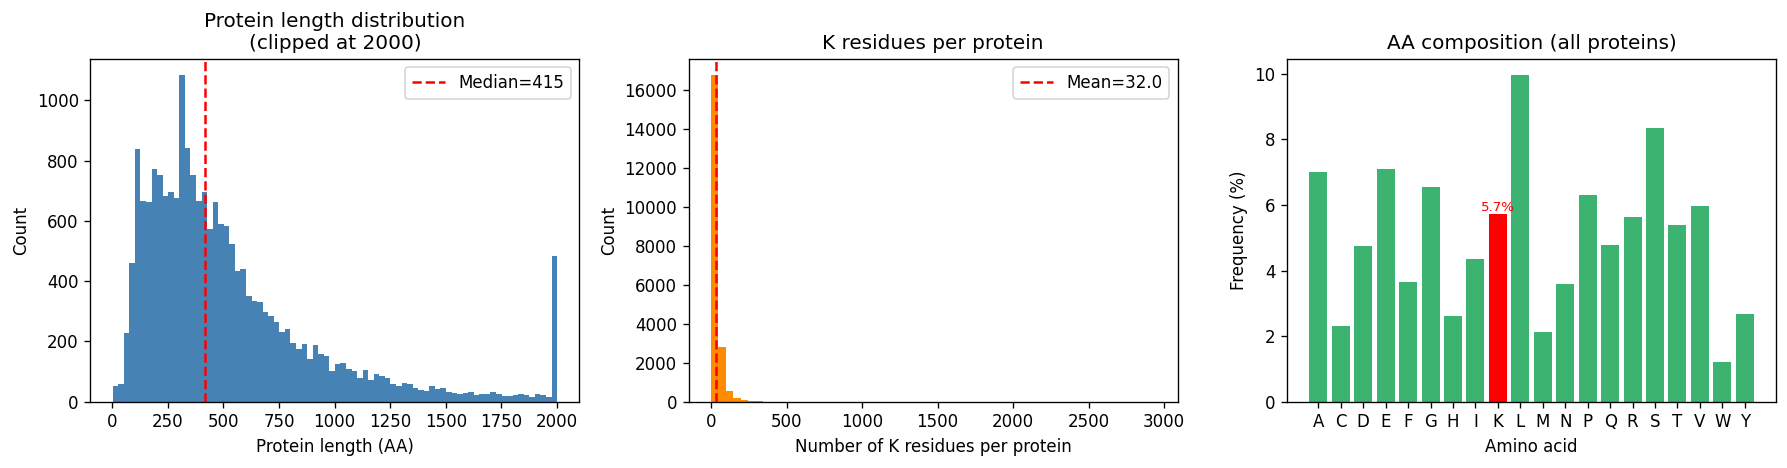


K frequency in human proteome: 5.73%
(For reference: 5-7% is typical for most organisms)


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Protein length histogram (clipped at 2000 for readability)
axes[0].hist([min(l, 2000) for l in lengths], bins=80, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Protein length (AA)")
axes[0].set_ylabel("Count")
axes[0].set_title("Protein length distribution\n(clipped at 2000)")
axes[0].axvline(np.median(lengths), color="red", linestyle="--", label=f"Median={int(np.median(lengths))}")
axes[0].legend()

# K count per protein
axes[1].hist(k_counts, bins=60, color="darkorange", edgecolor="none")
axes[1].set_xlabel("Number of K residues per protein")
axes[1].set_ylabel("Count")
axes[1].set_title("K residues per protein")
axes[1].axvline(np.mean(k_counts), color="red", linestyle="--", label=f"Mean={np.mean(k_counts):.1f}")
axes[1].legend()

# Amino acid frequency across all proteins
all_seq = "".join(s for _, _, s in proteins)
aa_counts = Counter(all_seq)
std_aa = "ACDEFGHIKLMNPQRSTVWY"
aa_freq = {aa: aa_counts.get(aa, 0) / len(all_seq) * 100 for aa in std_aa}
axes[2].bar(aa_freq.keys(), aa_freq.values(), color="mediumseagreen", edgecolor="none")
axes[2].set_xlabel("Amino acid")
axes[2].set_ylabel("Frequency (%)")
axes[2].set_title("AA composition (all proteins)")
# Highlight K
k_idx = list(std_aa).index("K")
axes[2].patches[k_idx].set_facecolor("red")
axes[2].text(k_idx, aa_freq["K"] + 0.1, f"{aa_freq['K']:.1f}%", ha="center", fontsize=8, color="red")

plt.tight_layout()
plt.show()

print(f"\nK frequency in human proteome: {aa_freq['K']:.2f}%")
print(f"(For reference: 5-7% is typical for most organisms)")

## 3. Extract K-windows (±15 AA around every K)

In [32]:
def extract_k_windows(proteins, window=15, pad_char="X"):
    """
    For every K in every protein, extract ±window AA window (total = 2*window+1 = 31).
    Positions too close to N/C terminus are padded with pad_char.
    
    Returns DataFrame with columns: uniprot_id, gene, k_position, seq_31
    """
    records = []
    W = window
    for uid, gene, seq in proteins:
        seq = seq.upper()
        for i, aa in enumerate(seq):
            if aa != "K":
                continue
            # Pad sequence at edges
            left  = seq[max(0, i-W) : i]
            right = seq[i+1 : i+W+1]
            left_pad  = pad_char * (W - len(left))
            right_pad = pad_char * (W - len(right))
            window_seq = left_pad + left + "K" + right + right_pad
            assert len(window_seq) == 2 * W + 1, f"Window length error: {len(window_seq)}"
            records.append({
                "uniprot_id":  uid,
                "gene":        gene,
                "k_position":  i,         # 0-indexed position of K in protein
                "protein_len": len(seq),
                "seq_31":      window_seq,
            })
    return pd.DataFrame(records)

df_windows = extract_k_windows(proteins, window=WINDOW)

print(f"Total K-windows extracted:   {len(df_windows):,}")
print(f"Unique proteins represented: {df_windows['uniprot_id'].nunique():,}")
print(f"Unique window sequences:     {df_windows['seq_31'].nunique():,}")
print(f"Duplicate windows:           {len(df_windows) - df_windows['seq_31'].nunique():,}")
print(f"\nSample:")
df_windows.head(5)

Total K-windows extracted:   654,299
Unique proteins represented: 20,299
Unique window sequences:     634,756
Duplicate windows:           19,543

Sample:


,uniprot_id,gene,k_position,protein_len,seq_31
0,A0A087X1C5,CP2D7_HUMAN,145,515,QRRFSVSTLRNLGLGKKSLEQWVTEEAACLC
1,A0A087X1C5,CP2D7_HUMAN,146,515,RRFSVSTLRNLGLGKKSLEQWVTEEAACLCA
2,A0A087X1C5,CP2D7_HUMAN,179,515,ADQAGRPFRPNGLLDKAVSNVIASLTCGRRF
3,A0A087X1C5,CP2D7_HUMAN,213,515,DPRFLRLLDLAQEGLKEESGFLREVLNAVPV
4,A0A087X1C5,CP2D7_HUMAN,238,515,LNAVPVLPHIPALAGKVLRFQKAFLTQLDEL


## 4. K-window properties

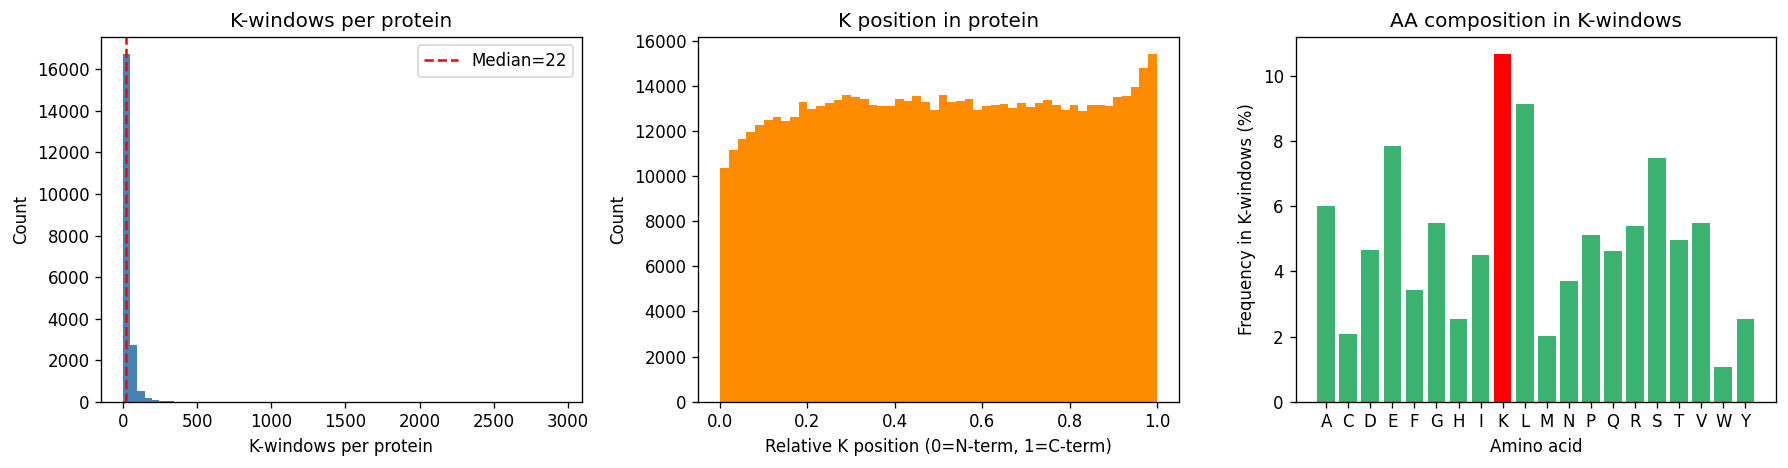

Windows with edge padding (X): 34,818 (5.3%)
  (these are K near N/C terminus — still valid, X maps to PAD token)


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# How many K windows per protein
wins_per_protein = df_windows.groupby("uniprot_id").size()
axes[0].hist(wins_per_protein, bins=60, color="steelblue", edgecolor="none")
axes[0].set_xlabel("K-windows per protein")
axes[0].set_ylabel("Count")
axes[0].set_title("K-windows per protein")
axes[0].axvline(wins_per_protein.median(), color="red", linestyle="--",
                label=f"Median={wins_per_protein.median():.0f}")
axes[0].legend()

# K position relative to protein length (N-term vs C-term bias?)
rel_pos = df_windows["k_position"] / df_windows["protein_len"]
axes[1].hist(rel_pos, bins=50, color="darkorange", edgecolor="none")
axes[1].set_xlabel("Relative K position (0=N-term, 1=C-term)")
axes[1].set_ylabel("Count")
axes[1].set_title("K position in protein")

# AA frequency in K-windows (position 15 = center K, excluded)
window_seqs = df_windows["seq_31"].str.cat()
w_aa_counts = Counter(window_seqs)
w_aa_freq = {aa: w_aa_counts.get(aa, 0) / len(window_seqs) * 100 for aa in std_aa}
axes[2].bar(w_aa_freq.keys(), w_aa_freq.values(), color="mediumseagreen", edgecolor="none")
axes[2].set_xlabel("Amino acid")
axes[2].set_ylabel("Frequency in K-windows (%)")
axes[2].set_title("AA composition in K-windows")
k_idx = list(std_aa).index("K")
axes[2].patches[k_idx].set_facecolor("red")

plt.tight_layout()
plt.show()

# Padding stats
n_padded = df_windows["seq_31"].str.contains("X").sum()
print(f"Windows with edge padding (X): {n_padded:,} ({n_padded/len(df_windows)*100:.1f}%)")
print(f"  (these are K near N/C terminus — still valid, X maps to PAD token)")

## 5. Compare with NHAC dataset

In [30]:
nhac = pd.read_csv("../data/genomics/NHAC_deduplicated.csv")

# How many NHAC sequences already exist in UniProt windows?
nhac_seqs   = set(nhac["seq_41"].tolist())
uniprot_seqs = set(df_windows["seq_31"].tolist())
overlap = nhac_seqs & uniprot_seqs

print("=== Dataset comparison ===")
print(f"NHAC sequences:              {len(nhac):,}")
print(f"  - positives (acetylated):  {nhac['label'].sum():,}")
print(f"  - negatives:               {(nhac['label']==0).sum():,}")
print(f"")
print(f"UniProt K-windows:           {len(df_windows):,}")
print(f"  - unique sequences:        {df_windows['seq_31'].nunique():,}")
print(f"")
print(f"NHAC sequences in UniProt:   {len(overlap):,} ({len(overlap)/len(nhac)*100:.1f}%)")
print(f"  (expected ~100% since NHAC comes from human proteins)")
print(f"")
print(f"Combined pretrain corpus:    ~{len(df_windows):,} sequences")
print(f"  vs current:                5,494 (NHAC only)")
print(f"  improvement factor:        {len(df_windows)/5494:.0f}x more pretraining data")

=== Dataset comparison ===
NHAC sequences:              5,494
  - positives (acetylated):  787
  - negatives:               4,707

UniProt K-windows:           654,299
  - unique sequences:        634,756

NHAC sequences in UniProt:   0 (0.0%)
  (expected ~100% since NHAC comes from human proteins)

Combined pretrain corpus:    ~654,299 sequences
  vs current:                5,494 (NHAC only)
  improvement factor:        119x more pretraining data


## 6. Save K-windows CSV for pretraining

In [31]:
# Deduplicate by sequence (keep first occurrence)
df_dedup = df_windows.drop_duplicates(subset="seq_31").reset_index(drop=True)

# Drop rows with non-standard AAs other than X (e.g. U=selenocysteine, B, Z, J)
# X is fine — maps to PAD. Others are rare but could confuse the tokenizer.
standard = set("ACDEFGHIKLMNPQRSTVWYX")
mask_clean = df_dedup["seq_31"].apply(lambda s: all(c in standard for c in s))
df_clean = df_dedup[mask_clean].reset_index(drop=True)

print(f"After deduplication:         {len(df_dedup):,}")
print(f"After removing non-standard: {len(df_clean):,}  (removed {len(df_dedup)-len(df_clean):,})")

df_clean.to_csv(OUT_CSV, index=False)
print(f"\nSaved to: {OUT_CSV}")
print(f"\nColumns: {list(df_clean.columns)}")
df_clean.head(3)

After deduplication:         634,756
After removing non-standard: 634,709  (removed 47)

Saved to: ../data/genomics/uniprot_kwindows.csv

Columns: ['uniprot_id', 'gene', 'k_position', 'protein_len', 'seq_31']


,uniprot_id,gene,k_position,protein_len,seq_31
0,A0A087X1C5,CP2D7_HUMAN,145,515,QRRFSVSTLRNLGLGKKSLEQWVTEEAACLC
1,A0A087X1C5,CP2D7_HUMAN,146,515,RRFSVSTLRNLGLGKKSLEQWVTEEAACLCA
2,A0A087X1C5,CP2D7_HUMAN,179,515,ADQAGRPFRPNGLLDKAVSNVIASLTCGRRF
